Завдання 1 Загрузить датасет Kaggle : Global YouTube Statistics 2023 за посиланням

Виконайте наступні завдання:

1. Прочитайте CSV файл (використовуйте метод read_csv):

2. Виведіть перші п'ять рядків (використовується метод head):

3. Виведіть розміри датасету (використовуйте метод shape):

4. Перевірте, чи у всіх рядків вистачає даних: виведіть кількість пропусків  у кожному зі стовпців (використовуйте методи isna та sum).
Якщо є пропуски, замінить їх на NaN, потім тип даних на числовий.

5. Замініть комірки з пропущеними значенями на середні за стовпцем. І тип даних на float.
6. Ще раз перевірте кількість пропусків.

7. Перевірте, скільки унікальних країн представлено у колонці "Country"

8. Побудуйте діаграму розподілу переглядів (використовуйте kind='hist'):

9. Визначте максимальну, мінімальну, середню кількість переглядів (використовуйте методи max, min, mean)

10.Знайдіть країну, де найбільше відео було завантажено на YouTube

11. Знайдіть відео (виведіть його назву) з найбільшою та найменшою кількістю завантажень uploads.


--- HEAD (5) ---
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0  

/tmp/ipykernel_180/1740566916.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


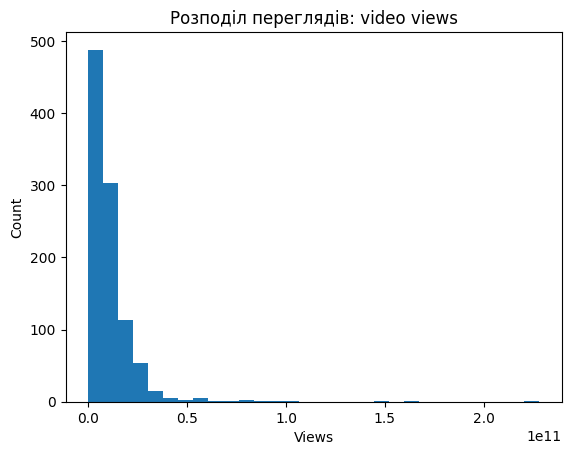


--- VIEWS STATS ---
max = 228000000000.0
min = 0.0
mean = 11039537052.03819

--- UPLOADS COLUMN USED: uploads ---

--- COUNTRY WITH MAX UPLOADS ---
Country
India    3728212.0
Name: uploads, dtype: float64

--- NAME COLUMN USED: Youtuber ---

--- MAX UPLOADS ---
Youtuber    ABP NEWS
uploads     301308.0
Name: 95, dtype: object

--- MIN UPLOADS ---
Youtuber    Music
uploads       0.0
Name: 5, dtype: object


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Прочитайте CSV файл (read_csv)
PATH_YT = "/content/GlobalYouTubeStatistics.csv"
df = pd.read_csv(PATH_YT, encoding="latin-1")

# 2) Перші 5 рядків (head)
print("\n--- HEAD (5) ---")
print(df.head())

# 3) Розміри датасету (shape)
print("\n--- SHAPE ---")
print(df.shape)

# 4) Пропуски по колонках (isna + sum). Якщо є пропуски, то замінити на NaN і перевести числові колонки у numeric.
print("\n--- MISSING VALUES (before) ---")
missing_before = df.isna().sum()
print(missing_before[missing_before > 0].sort_values(ascending=False))

# заміна типових значень на NaN
df = df.replace(["", " ", "None", "null", "NULL", "NaN"], np.nan)

# конвертація числових колонок (де можливо)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

# 5) Замінити пропуски в числових колонках на середнє + тип float
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].apply(lambda s: pd.to_numeric(s, errors="coerce"))
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[num_cols] = df[num_cols].astype(float)

# 6) Перевірка пропусків ще раз
print("\n--- MISSING VALUES (after) ---")
missing_after = df.isna().sum()
print(missing_after[missing_after > 0].sort_values(ascending=False))

print("\n--- COLUMNS ---")
print(list(df.columns))

# 7) Скільки унікальних країн у Country
print("\n--- UNIQUE COUNTRIES ---")
print(df["Country"].nunique())

# 8) Гістограма переглядів (views)
view_candidates = [c for c in df.columns if "view" in c.lower()]
if len(view_candidates) == 0:
    print("\n[УВАГА] Не знайшов колонку з 'view' у назві. Подивись список df.columns і задай views_col вручну.")
else:
    views_col = view_candidates[0]
    print(f"\n--- VIEWS COLUMN USED: {views_col} ---")
    df[views_col].plot(kind="hist", bins=30)
    plt.title(f"Розподіл переглядів: {views_col}")
    plt.xlabel("Views")
    plt.ylabel("Count")
    plt.show()

    # 9) max/min/mean переглядів
    print("\n--- VIEWS STATS ---")
    print("max =", df[views_col].max())
    print("min =", df[views_col].min())
    print("mean =", df[views_col].mean())

# 10) Країна, де найбільше uploads
upload_candidates = [c for c in df.columns if "upload" in c.lower()]
if len(upload_candidates) == 0:
    print("\n[УВАГА] Не знайшов колонку з 'upload'. Подивись df.columns і задай uploads_col вручну.")
else:
    uploads_col = upload_candidates[0]
    print(f"\n--- UPLOADS COLUMN USED: {uploads_col} ---")

    country_uploads = df.groupby("Country")[uploads_col].sum().sort_values(ascending=False)
    print("\n--- COUNTRY WITH MAX UPLOADS ---")
    print(country_uploads.head(1))

    # 11) Назва каналу/відео з max/min uploads
    name_candidates = [c for c in df.columns if any(k in c.lower() for k in ["youtuber", "channel", "title", "name"])]
    if len(name_candidates) == 0:
        print("\n[УВАГА] Не знайшов колонку з назвою (youtuber/channel/title/name). Подивись df.columns і задай name_col вручну.")
    else:
        name_col = name_candidates[0]
        print(f"\n--- NAME COLUMN USED: {name_col} ---")

        max_row = df.loc[df[uploads_col].idxmax(), [name_col, uploads_col]]
        min_row = df.loc[df[uploads_col].idxmin(), [name_col, uploads_col]]

        print("\n--- MAX UPLOADS ---")
        print(max_row)
        print("\n--- MIN UPLOADS ---")
        print(min_row)

Завдання 2.  

Скачайте датасет  Amazon Top 50 Bestselling Books 2009 – 2019, що знаходиться  за посиланням

 Набір даних із 50 найбільш продаваних книг Amazon з 2009 по 2019 рік. Містить 550 книг, дані були розділені на художню літературу та нон-фікшн за допомогою Goodreads.

Завдання
Прочитайте csv файл (метод read_csv)

Виведіть перші 10 рядків (метод head)

Виведіть розміри датасету (метод shape)

Про скільки книг зберігає дані датасет?

Змініть назви всіх колонок: назва з маленької букви, без пробілів через підкреслення.

df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

Вивести кількість пропусків у кожному стовпчику.

Чи є в якихось змінних пропуски? (Так / ні)

За допомогою методу unique  перевірте. Які є унікальні жанри в стовпці genre  

Які є унікальні жанри?

Визначте максимальну, мінімальну, медіанну ціну за допомогою методів  max, min, mean, median

Максимальна ціна?

Мінімальна ціна?

Середня ціна?

Медіанна ціна?

8.Виконайте наступні завдання з пошуку і сортування даних

Який рейтинг у датасеті найвищий?  

Скільки книг мають такий рейтинг?  

Яка книга має найбільше відгуків?  

З тих книг, що потрапили до Топ-50 у 2010 році, яка книга найдорожча ?

Скільки книг жанру Fiction потрапили до Топ-50 у 2012 році  

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або метод isin)?  

Вивести максимальну і  мінімальну ціну для жанру Fiction I NonFiction (за допомогою методів  groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Використовуйте тількі потрібні вам стовпці.

Збережіть файл. Прізвище_ЛР_2.ipynb

In [8]:
import pandas as pd
import numpy as np

# 1) Прочитайте csv файл (read_csv)
PATH_AMZ = "/content/bestsellerswithcategories.csv"
df2 = pd.read_csv(PATH_AMZ)

# 2) Перші 10 рядків
print("\n--- HEAD (10) ---")
print(df2.head(10))

# 3) Розміри датасету
print("\n--- SHAPE ---")
print(df2.shape)

# 4) Про скільки книг зберігає дані датасет?
rows_count = df2.shape[0]
unique_books = df2["Name"].nunique() if "Name" in df2.columns else None
print("\n--- COUNT ---")
print("К-сть записів (рядків):", rows_count)
print("К-сть унікальних книг (за Name):", unique_books)

# 5) Змінити назви колонок як в умові
df2.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
print("\n--- COLUMNS AFTER RENAME ---")
print(list(df2.columns))

# 6) Пропуски у кожному стовпчику
print("\n--- MISSING VALUES ---")
miss = df2.isna().sum()
print(miss)

# 7) Чи є пропуски? (Так/Ні)
has_missing = (miss.sum() > 0)
print("\n--- ANY MISSING? ---")
print("Так" if has_missing else "Ні")

# 8) Унікальні жанри
print("\n--- UNIQUE GENRES ---")
print(df2["genre"].unique())

# 9) max/min/mean/median ціни
print("\n--- PRICE STATS ---")
print("Максимальна:", df2["price"].max())
print("Мінімальна:", df2["price"].min())
print("Середня:", df2["price"].mean())
print("Медіанна:", df2["price"].median())

# Найвищий рейтинг
top_rating = df2["user_rating"].max()
print("\n--- TOP RATING ---")
print(top_rating)

# Скільки книг мають такий рейтинг
print("\n--- COUNT OF BOOKS WITH TOP RATING ---")
print((df2["user_rating"] == top_rating).sum())

# Яка книга має найбільше відгуків
print("\n--- BOOK WITH MAX REVIEWS ---")
print(df2.loc[df2["reviews"].idxmax(), ["name", "author", "reviews"]])

# З тих книг, що у топ-50 у 2010 році, яка найдорожча
df2_2010 = df2[df2["year"] == 2010]
print("\n--- MOST EXPENSIVE BOOK IN 2010 ---")
print(df2_2010.loc[df2_2010["price"].idxmax(), ["name", "author", "price", "year", "genre"]])

# Скільки Fiction у 2012 році
print("\n--- FICTION COUNT IN 2012 ---")
print(((df2["year"] == 2012) & (df2["genre"] == "Fiction")).sum())

# Скільки книг з рейтингом 4.9 у 2010 та 2011 роках
mask = df2["year"].isin([2010, 2011]) & (df2["user_rating"] == 4.9)
print("\n--- RATING 4.9 IN 2010 & 2011 ---")
print(df2[mask].shape[0])

# max/min ціни для Fiction і Non Fiction (groupby + agg)
print("\n--- MIN/MAX PRICE BY GENRE ---")
print(df2.groupby("genre")["price"].agg(["min", "max"]))


--- HEAD (10) ---
                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   
5      A Dance with Dragons (A Song of Ice and Fire)   
6  A Game of Thrones / A Clash of Kings / A Storm...   
7                     A Gentleman in Moscow: A Novel   
8      A Higher Loyalty: Truth, Lies, and Leadership   
9                          A Man Called Ove: A Novel   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424   